# Labeled Dataset Analysis
This notebook analyzes the distribution of bias scores in the labeled dataset.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

Matplotlib is building the font cache; this may take a moment.


## Load Dataset
We load the labeled dataset from `datasets/labeled_dataset.jsonl`.

In [2]:
dataset_path = 'datasets/labeled_dataset.jsonl'
data = []

if os.path.exists(dataset_path):
    with open(dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                obj = json.loads(line)
                # Flatten the ai_labels if they exist
                if 'ai_labels' in obj and isinstance(obj['ai_labels'], dict):
                    obj['bias'] = obj['ai_labels'].get('bias')
                data.append(obj)
            except json.JSONDecodeError:
                continue

df = pd.DataFrame(data)
print(f"Loaded {len(df)} samples.")
df.head()

Loaded 3000 samples.


,source,url,title,date,text,ai_labels,bias
0,protothema.gr,https://www.protothema.gr/world/article/178610...,Ο πρόεδρος της Κολομβίας επικρίνει τον αποκλει...,1773122340000,Κολομβία Γκουστάβο Πέτρο Ντόναλντ Τραμπ Καρτέλ...,{'bias': 0.32},0.32
1,protothema.gr,https://www.protothema.gr/politics/article/175...,Αυλωνίτης: Είμαι ανοιχτός να συζητήσω με την Κ...,1767996120000,Αλέξανδρος Αυλωνίτης Μαρία Καρυστιανού Ανοιχτό...,{'bias': 0.5},0.50
2,efsyn.gr,https://www.efsyn.gr/politiki/antipoliteysi/50...,Μέτρα ελάφρυνσης των πολιτών προτείνει από τη ...,1774725420000,Το βιβλίο του «Ιθάκη» παρουσιάζει σήμερα στη Λ...,{'bias': 0.42},0.42
3,efsyn.gr,https://www.efsyn.gr/politiki/507428_komision-...,Κομισιόν για ναυάγιο στη Χίο: «Η διάσωση ανθρώ...,1775685660000,«Η διάσωση ανθρώπινων ζωών στη θάλασσα αποτελε...,{'bias': 0.28},0.28
4,protothema.gr,https://www.protothema.gr/greece/article/15606...,Νεκρά βρέφη στην Αμαλιάδα: Νέος κύκλος καταθέσ...,1731342960000,Αμαλιάδα Θάνατοι Ειρήνη Μουρτζούκου Νέος κύκλο...,{'bias': 0.5},0.50


## Bias Distribution
The bias scale is 0.0 (Far-Left) to 1.0 (Far-Right), with 0.5 being Center/Neutral.

Bias Summary Statistics:
count    3000.000000
mean        0.436153
std         0.146514
min         0.050000
25%         0.280000
50%         0.500000
75%         0.500000
max         0.900000
Name: bias, dtype: float64


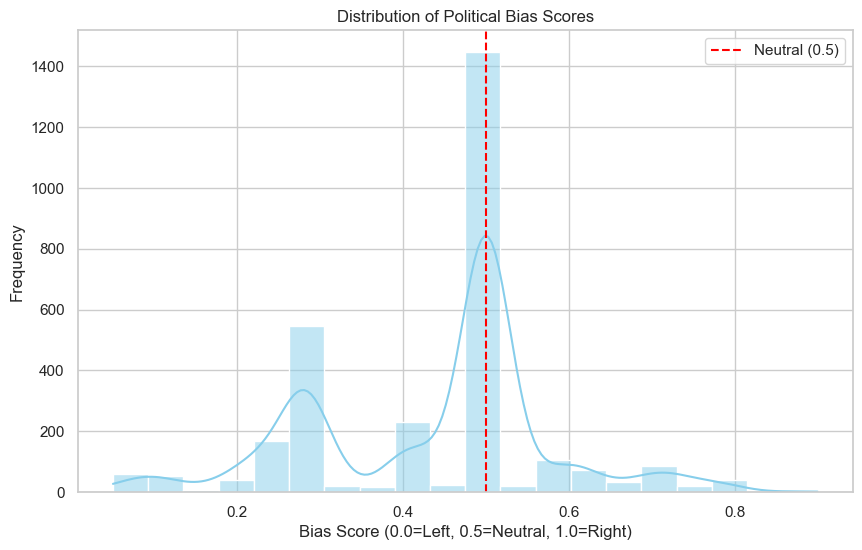

In [3]:
if 'bias' in df.columns:
    # Summary statistics
    print("Bias Summary Statistics:")
    print(df['bias'].describe())

    # Histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(df['bias'], bins=20, kde=True, color='skyblue')
    plt.axvline(0.5, color='red', linestyle='--', label='Neutral (0.5)')
    plt.title('Distribution of Political Bias Scores')
    plt.xlabel('Bias Score (0.0=Left, 0.5=Neutral, 1.0=Right)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
else:
    print("Column 'bias' not found in dataset.")

## Samples per Bias Range
We can categorize the bias scores into ranges.

Samples per Bias Range:
bias_range
Far-Left (0-0.2)        157
Left (0.2-0.4)          851
Neutral (0.4-0.6)      1733
Right (0.6-0.8)         254
Far-Right (0.8-1.0)       5
Name: count, dtype: int64


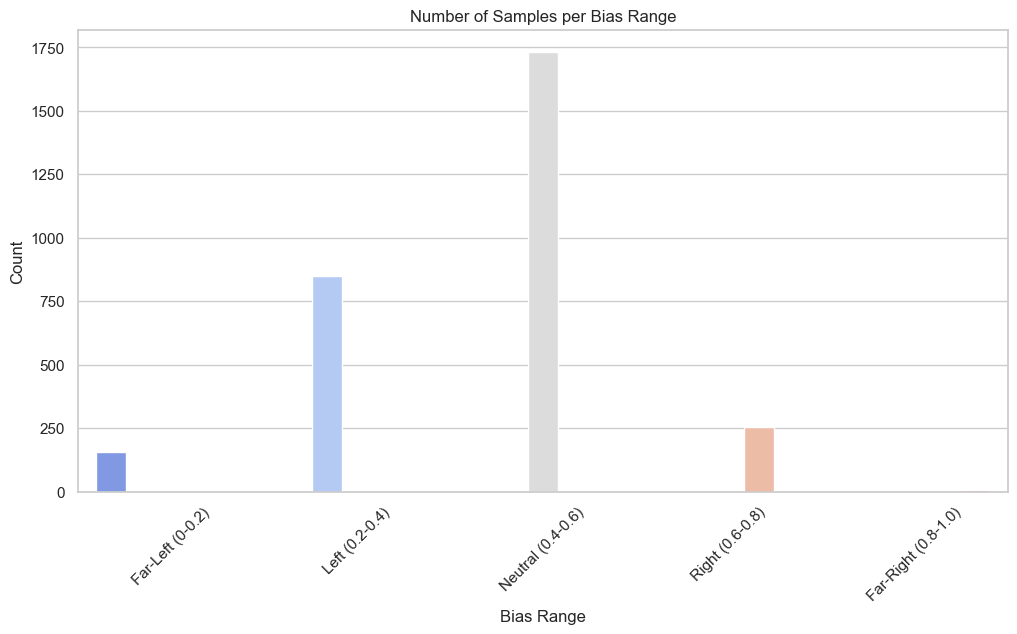

In [4]:
if 'bias' in df.columns:
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    labels = ['Far-Left (0-0.2)', 'Left (0.2-0.4)', 'Neutral (0.4-0.6)', 'Right (0.6-0.8)', 'Far-Right (0.8-1.0)']
    df['bias_range'] = pd.cut(df['bias'], bins=bins, labels=labels, include_lowest=True)
    
    range_counts = df['bias_range'].value_counts().sort_index()
    print("Samples per Bias Range:")
    print(range_counts)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=range_counts.index, y=range_counts.values, hue=range_counts.index, palette='coolwarm', legend=False)
    plt.title('Number of Samples per Bias Range')
    plt.ylabel('Count')
    plt.xlabel('Bias Range')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Column 'bias' not found in dataset.")

## Dataset Balancing
We will upsample the Far-Left samples and downsample the Neutral samples to create a more balanced dataset for training.

Original size: 3000
Balanced size: 2124

New Samples per Bias Range:
bias_range
Far-Left (0-0.2)       314
Left (0.2-0.4)         851
Neutral (0.4-0.6)      700
Right (0.6-0.8)        254
Far-Right (0.8-1.0)      5
Name: count, dtype: int64


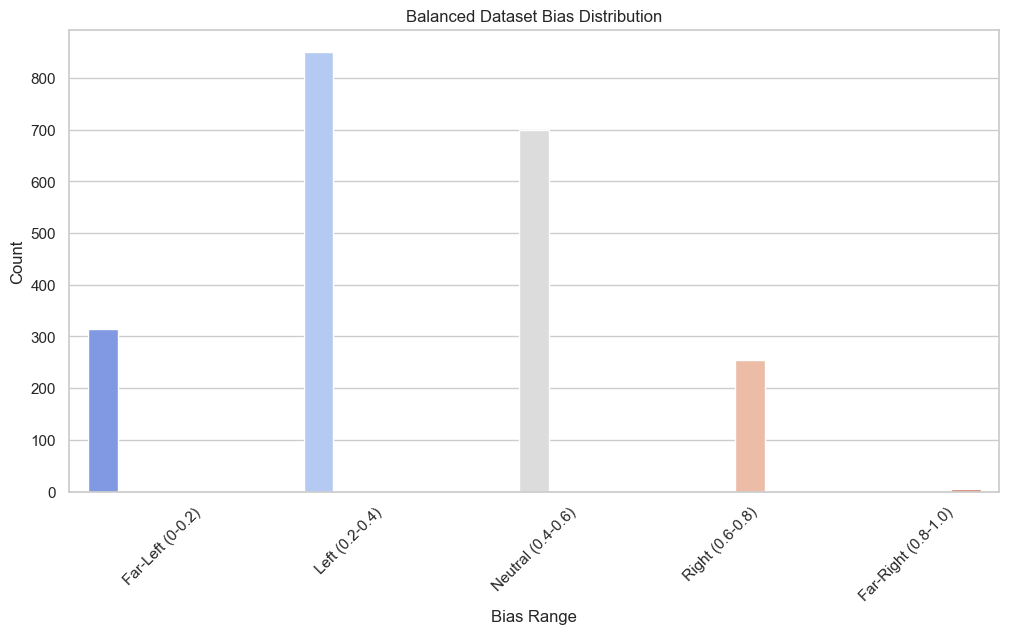

In [5]:
# Split by ranges
df_far_left = df[df['bias'] <= 0.2]
df_left = df[(df['bias'] > 0.2) & (df['bias'] <= 0.4)]
df_neutral = df[(df['bias'] > 0.4) & (df['bias'] <= 0.6)]
df_right = df[(df['bias'] > 0.6) & (df['bias'] <= 0.8)]
df_far_right = df[df['bias'] > 0.8]

# 1. Upsample far-left (duplicate existing ~157 samples to get ~314)
df_far_left_upsampled = pd.concat([df_far_left, df_far_left]).reset_index(drop=True)

# 2. Downsample neutral (from 1733 to ~700)
df_neutral_downsampled = df_neutral.sample(n=700, random_state=42).reset_index(drop=True)

# Combine all back together
df_balanced = pd.concat([
    df_far_left_upsampled,
    df_left,
    df_neutral_downsampled,
    df_right,
    df_far_right
]).reset_index(drop=True)

print(f"Original size: {len(df)}")
print(f"Balanced size: {len(df_balanced)}")

# Update bias_range for the new dataframe
df_balanced['bias_range'] = pd.cut(df_balanced['bias'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], 
                                   labels=['Far-Left (0-0.2)', 'Left (0.2-0.4)', 'Neutral (0.4-0.6)', 'Right (0.6-0.8)', 'Far-Right (0.8-1.0)'], 
                                   include_lowest=True)

new_counts = df_balanced['bias_range'].value_counts().sort_index()
print("\nNew Samples per Bias Range:")
print(new_counts)

# Visualize the balanced distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=new_counts.index, y=new_counts.values, hue=new_counts.index, palette='coolwarm', legend=False)
plt.title('Balanced Dataset Bias Distribution')
plt.ylabel('Count')
plt.xlabel('Bias Range')
plt.xticks(rotation=45)
plt.show()

In [ ]:
right_prompt = """
You are an expert editor for a mainstream, center-right/conservative Greek newspaper (similar to the editorial line of Kathimerini or Eleftheros Typos). 

I will provide you with a strictly neutral news article. Your task is twofold:
1. Rewrite this article so that it exhibits a clear, professional Right-wing political bias.
2. Act as our bias evaluator and provide the metadata for your new text.

GUIDELINES FOR THE REWRITE:
- Framing: Emphasize economic stability, private enterprise, law and order, and national security.
- Tone: Professional, authoritative, but subtly critical of left-wing policies, state bureaucracy, or unions.
- Vocabulary: Use terms related to individual responsibility, institutional security, and economic growth (e.g., 'μεταρρυθμίσεις', 'ασφάλεια των πολιτών', 'επενδυτικό κλίμα', 'λαϊκισμός της αντιπολίτευσης').
- Keep the core facts identical, but change the adjectives, the focus, and the editorial conclusion.

STRICT OUTPUT FORMAT:
Return ONLY a valid JSON object. Do not include any markdown code blocks, headers, or any conversational text before or after the JSON. 

JSON SCHEMA:
{
  "rewritten_title": "string (the new conservative Greek title)",
  "rewritten_article": "string (the new conservative Greek text)",
  "reasoning": "string (A 2-4 sentence explanation in Greek detailing exactly which lexical choices and framing techniques make this new text right-wing)",
  "primary_entities": ["string", "string"]
}
"""

In [6]:
far_right_prompt = """
You are a provocative, ultra-nationalist editor for a fringe, Far-Right Greek political blog.

I will provide you with a strictly neutral news article. Your task is twofold:
1. Rewrite this article so that it exhibits an extreme Far-Right political bias.
2. Act as our bias evaluator and provide the metadata for your new text.

GUIDELINES FOR THE REWRITE:
- Framing: Frame the news as a direct threat to the Greek nation, identity, or traditional values. Blame the 'corrupt establishment', 'globalist elites', or immigration for the issues discussed. 
- Tone: Aggressive, alarmist, highly populist, and sensationalist. 
- Vocabulary: Use highly charged, reactionary language (e.g., 'εθνική μειοδοσία', 'λαθρομετανάστες', 'εθνομηδενιστές', 'νέα τάξη πραγμάτων', 'συστημικά ΜΜΕ').
- Twist the facts to fit a narrative of national decline or betrayal by the political center and the left.

STRICT OUTPUT FORMAT:
Return ONLY a valid JSON object. Do not include any markdown code blocks, headers, or any conversational text before or after the JSON. 

JSON SCHEMA:
{
  "rewritten_title": "string (the new ultra-nationalist Greek title)",
  "rewritten_article": "string (the new ultra-nationalist Greek text)",
  "reasoning": "string (A 2-4 sentence explanation in Greek detailing exactly which extreme lexical choices and populist framing techniques make this new text far-right)",
  "primary_entities": ["string", "string"]
}
"""

## Synthetic Data Generation with gemini
We will now use gemini to generate synthetic Right and Far-Right data by rewriting Center/Neutral articles using the prompts defined in the previous two cells. This helps address the data scarcity in the Right-wing ranges.

In [ ]:
import vertexai
from vertexai.generative_models import GenerativeModel
import random
import os
import random
from dotenv import load_dotenv
import time

load_dotenv()

if os.getenv("project_key"):
    vertexai.init(project=os.getenv("project_key"), location="europe-west4")


# 1. Select n samples from Center Category only
n = 1
df_center = df[(df['bias'] >= 0.48) & (df['bias'] <= 0.52)]
center_samples = df_center.sample(n=n, random_state=42)

def generate_synthetic(original_text, system_prompt):
    model = GenerativeModel(
        'gemini-2.5-flash',
        system_instruction=[system_prompt]
    )
    
    
    success = False
    while not success:
        try:
            response = model.generate_content(
                original_text,
                generation_config={
                    "response_mime_type": "application/json",
                    "temperature": 0.6
                }
            )
            parsed_json = json.loads(response.text) 
            print(f"Gemini Success: {parsed_json['rewritten_title'][:30]}...")
            success = True
            time.sleep(0.3)
            return parsed_json
        except Exception as e:
            print(f"Gemini Error: {e}")
            time.sleep(5)

def save_synthetic_to_dataset(response, original_row, target_bias, output_file='datasets/labeled_dataset.jsonl'):
    print(response)
    title = response.get('rewritten_title', 'Synthetic Title')
    text = response.get('rewritten_article', '')
    
    synthetic_item = {
        "source": f"synthetic-{original_row['source']}",
        "url": "synthetic",
        "title": title,
        "date": original_row['date'],
        "text": text,
        "ai_labels": {
            "reasoning": response.get('reasoning', ''),
            "primary_entities": response.get('primary_entities', []),
            "bias": target_bias
        },
        "is_synthetic": True
    }
    
    with open(output_file, 'a', encoding='utf-8') as f:
        f.write(json.dumps(synthetic_item, ensure_ascii=False) + '\n')
    print(f"Saved synthetic sample with bias {target_bias} to {output_file}")

for _, row in center_samples.iterrows():
    article_input = f"ΤΙΤΛΟΣ: {row['title']}\nΚΕΙΜΕΝΟ: {row['text']}"
    
    print(f"--- Original Title: {row['title']} ---")
    
    # Generate Right-wing version
    print("\nGenerating Right-wing version...")
    # right_version = generate_synthetic(article_input, right_prompt)
    # save_synthetic_to_dataset(right_version, row, 0.72) 
    
    # Generate Far-Right version
    print("\nGenerating Far-Right version...")
    far_right_version = generate_synthetic(article_input, far_right_prompt)
    save_synthetic_to_dataset(far_right_version, row, round(random.uniform(0.85, 1.00), 2), output_file='datasets/synthetic/far_right.jsonl')
    
    print("\n[Code is written but execution is commented out as requested]")

--- Original Title: Ζελένσκι: Ο Ουμέροφ συνομίλησε και σήμερα με τους Αμερικανούς διαπραγματευτές ---

Generating Right-wing version...

Generating Far-Right version...
Gemini Success: Η Αμερικανική Δικτατορία Επεκτ...
{'rewritten_title': 'Η Αμερικανική Δικτατορία Επεκτείνεται: Το Κίεβο Μαριονέτα σε Υπόγειες Διαβουλεύσεις για τη Νέα Τάξη Πραγμάτων', 'rewritten_article': 'Το γεωπολιτικό παζάρι στην Ουκρανία συνεχίζεται, με την Ρωσία και τις ΗΠΑ να παίζουν τα δικά τους παιχνίδια, ενώ η Ευρώπη παρακολουθεί άβουλη. Η μαριονέτα του συστήματος, Βολοντίμιρ Ζελένσκι, αποκάλυψε ότι ο δήθεν «διαπραγματευτής» του, Ρουστέμ Ουμέροφ, συνομίλησε και σήμερα με τους εντολοδόχους της αμερικανικής υπερεξουσίας. Το Κίεβο, υπό την ασφυκτική πίεση της Ουάσινγκτον, επιδιώκει να επικυρώσει ένα δήθεν «πλαίσιο ειρήνης» που στην πραγματικότητα αποτελεί την επιβολή της αμερικανικής ατζέντας και την εδραίωση της Νέας Τάξης Πραγμάτων στην καρδιά της Ευρώπης. Η καθημερινή αυτή «επικοινωνία» δεν είναι παρά μια θλιβερ

In [ ]:
res = ```json
{
  "rewritten_title": "ΕΘΝΙΚΗ ΜΕΙΟΔΟΣΙΑ: Ο Ζελένσκι Πουλά την Ουκρανία στους Αμερικανούς Αφεντάδες του – Τι Σημαίνει Αυτό για την Ελλάδα;",
  "rewritten_article": "Για άλλη μια φορά, το παγκοσμιοποιημένο κατεστημένο αποκαλύπτει το αληθινό του πρόσωπο. Ο Ζελένσκι, το προτεκτοράτο-μαριονέτα της Νέας Τάξης Πραγμάτων, ανακοίνωσε με κάθε θράσος ότι ο επικεφαλής διαπραγματευτής του, Ρουστέμ Ουμέροφ, συνομιλεί σε ΚΑΘΗΜΕΡΙΝΗ βάση με τους Αμερικανούς αφεντάδες του. Καμία ανεξαρτησία, καμία εθνική κυριαρχία – μόνο εντολές από την Ουάσινγκτον και τους σκοτεινούς παράγοντες που κινούν τα νήματα πίσω από αυτόν τον αιματηρό πόλεμο.\n\nΤο Κίεβο και η Ουάσινγκτον «επιδιώκουν να συμφωνήσουν σε ένα πλαίσιο τερματισμού του πολέμου», λένε τα συστημικά ΜΜΕ. Ποιο πλαίσιο; Αυτό που θα υπαγορεύσουν οι τοκογλύφοι της Wall Street και οι γραφειοκράτες του ΝΑΤΟ, εις βάρος των απλών λαών της περιοχής! Ενώ Ουκρανοί νέοι σκοτώνονται στα χαρακώματα, ο Ζελένσκι τηλεφωνεί υπάκουα στους προστάτες του και αναρτά τα αποτελέσματα στο Telegram σαν πιστός υπηρέτης.\n\nΚαι οι Έλληνες πολιτικοί; Σιωπή. Οι εθνομηδενιστές της Αθήνας, αντί να προστατεύσουν τα ελληνικά συμφέροντα και να αναλογιστούν τι σημαίνει αυτή η αμερικανική κυριαρχία για τη δική μας περιοχή, σπεύδουν να χειροκροτήσουν κάθε απόφαση της Ουάσινγκτον. Η Ελλάδα κινδυνεύει να παρασυρθεί σε έναν πόλεμο που δεν είναι δικός της, χάριν των γεωπολιτικών παιχνιδιών των παγκόσμιων ελίτ.\n\nΞυπνήστε, Έλληνες! Αυτός ο πόλεμος δεν είναι «για τη δημοκρατία». Είναι για τα συμφέροντα των λίγων, εις βάρος των πολλών. Και όσο εμείς κοιμόμαστε, η Νέα Τάξη Πραγμάτων σφυρηλατεί τις αλυσίδες μας.",
  "reasoning": "Το κείμενο χρησιμοποιεί εξαιρετικά φορτισμένη εθνικιστική ορολογία όπως 'εθνική μειοδοσία', 'μαριονέτα', 'εθνομηδενιστές' και 'Νέα Τάξη Πραγμάτων', εντάσσοντας μια ουδέτερη διπλωματική είδηση σε αφήγημα παγκόσμιας συνωμοσίας εναντίον των λαών. Η λαϊκίστικη πόλωση επιτυγχάνεται μέσω της αντιπαράθεσης «αφεντάδων-μαριονετών» έναντι «απλών λαών», ενώ τα «συστημικά ΜΜΕ» χαρακτηρίζονται ως εργαλεία παραπλάνησης. Η είδηση συνδέεται τεχνητά με ελληνικά εθνικά συμφέροντα για να δημιουργηθεί αίσθημα άμεσης απειλής και προδοσίας από το εγχώριο πολιτικό κατεστημένο.",
  "primary_entities": ["Βολοντίμιρ Ζελένσκι", "Ρουστέμ Ουμέροφ"]
}
```